# Tricy Table Data Solution

In [1]:
!unzip -q -o ./Data/neoai-2025-tricy-table-data -d ./Data/

## Dependencies

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from tqdm.cli import tqdm
from tqdm import trange

In [3]:
train_df = pd.read_csv("./Data/train_tables.csv")
test_df = pd.read_csv("./Data/test_tables.csv")
sample_df = pd.read_csv("./Data/sample_submission.csv")

## EDA

In [4]:
train_df.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,day,hour,minute,target
0,470.933685,NaN,20.341982,87.061722,2854.097632,52.455972,2744.457436,1331.064839,653.024118,2.0,4.0,34.0,767.518101
1,322.752334,1706.970061,20.208099,NaN,2962.979989,41.355108,1690.248184,1198.654829,636.739861,2.0,10.0,43.0,399.809849
2,437.018615,2488.229729,20.234919,83.672355,2873.775118,48.856837,2441.896999,1319.009963,651.866006,NaN,10.0,43.0,678.723321
3,286.164002,NaN,20.388649,73.363886,2947.575123,37.927285,1487.642316,1139.463820,538.749367,2.0,16.0,2.0,263.499775
4,437.593246,2481.820613,20.492803,82.674960,2836.678634,NaN,2428.457628,NaN,642.256715,1.0,12.0,52.0,679.299660


In [5]:
test_df.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,day,hour,minute,id
0,457.008442,NaN,20.181569,84.596243,2856.659366,NaN,2544.418381,NaN,644.240441,1.0,18.0,43.0,0
1,446.657066,2533.300979,20.436051,84.450941,2897.636139,49.893098,2507.359961,1322.860255,650.385119,2.0,1.0,49.0,1
2,523.784254,2945.959678,20.251782,86.819573,NaN,52.950622,2928.299439,NaN,649.844113,1.0,4.0,2.0,2
3,441.081405,2550.833526,20.288787,84.005320,NaN,NaN,NaN,1318.855760,NaN,2.0,2.0,14.0,3
4,NaN,2574.342039,20.479995,83.448487,2878.257006,49.108300,2518.966718,1306.454903,642.635453,2.0,6.0,33.0,4


In [6]:
train_df.shape

(40704, 13)

In [7]:
test_df.shape

(22378, 13)

In [8]:
train_df.isna().sum()

feat_0    3616
feat_1    3479
feat_2    4482
feat_3    4585
feat_4    3601
feat_5    4628
feat_6    4406
feat_7    4740
feat_8    4297
day       4651
hour      4275
minute    3528
target       0
dtype: int64

In [9]:
test_df.isna().sum()

feat_0    2022
feat_1    1906
feat_2    2467
feat_3    2637
feat_4    2062
feat_5    2589
feat_6    2517
feat_7    2478
feat_8    2322
day       2515
hour      2346
minute    2049
id           0
dtype: int64

In [10]:
def eda_num(col):
    plt.title(f"Train {col} boxplot")
    sns.boxplot(train_df[col])
    plt.show()

    plt.title(f"Test {col} boxplot")
    sns.boxplot(test_df[col])
    plt.show()

    plt.title(f"Train {col} histplot")
    sns.histplot(train_df[col])
    plt.show()

    plt.title(f"Test {col} hitsplot")
    sns.histplot(test_df[col])
    plt.show()

    plt.title(f"Train {col} to target")
    sns.scatterplot(train_df, x=col, y='target')

### feature 0

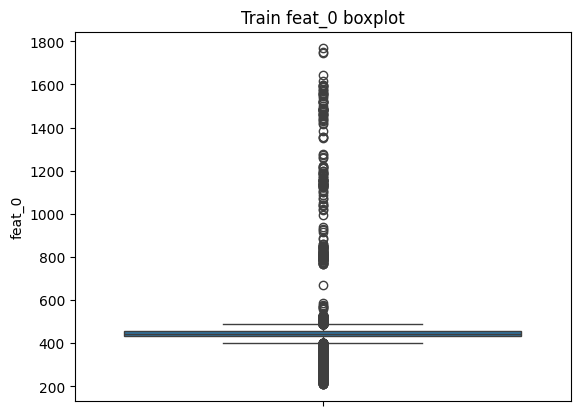

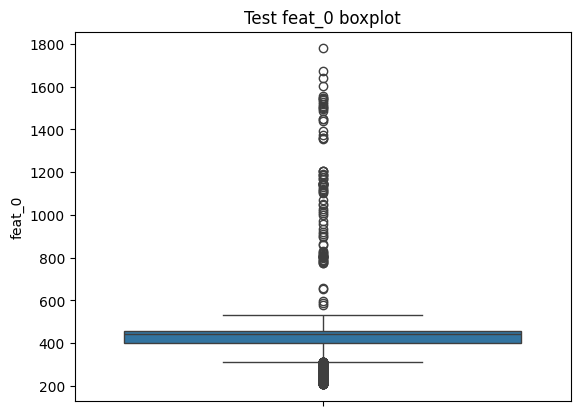

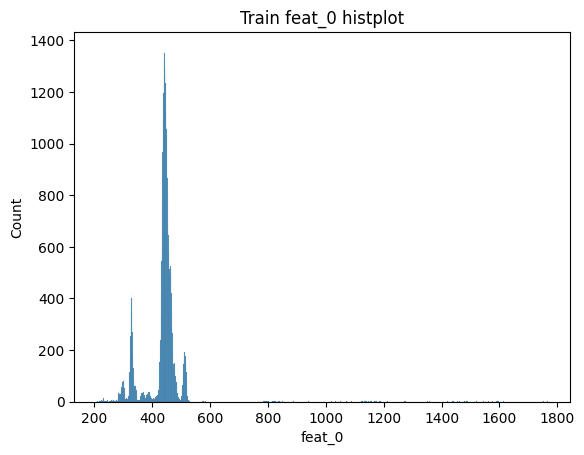

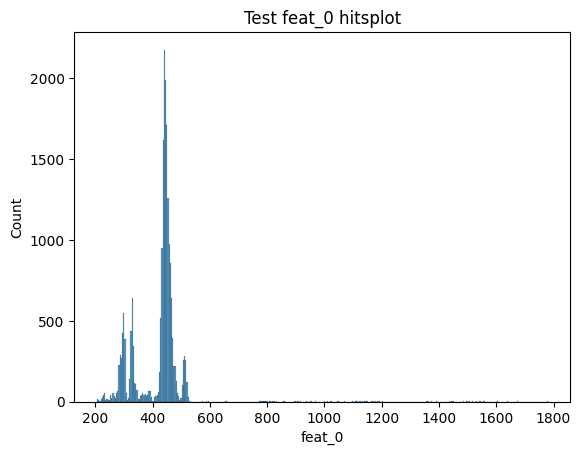

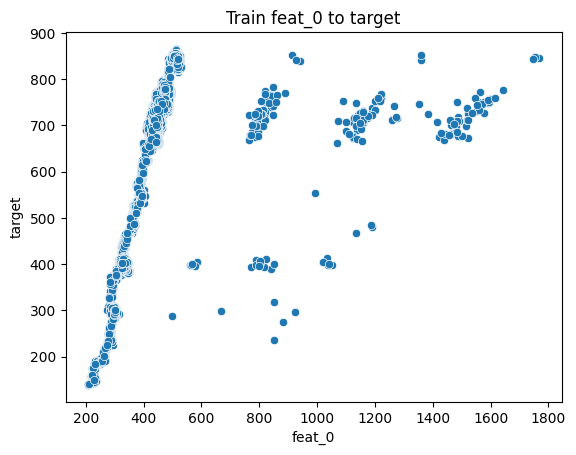

In [11]:
eda_num("feat_0")

Поделить feat_0 на группы. Линреги

### feature 1

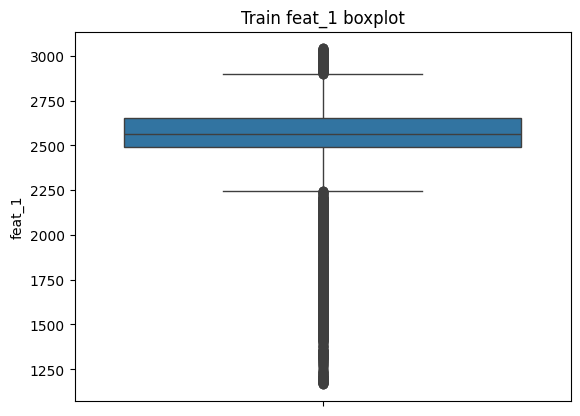

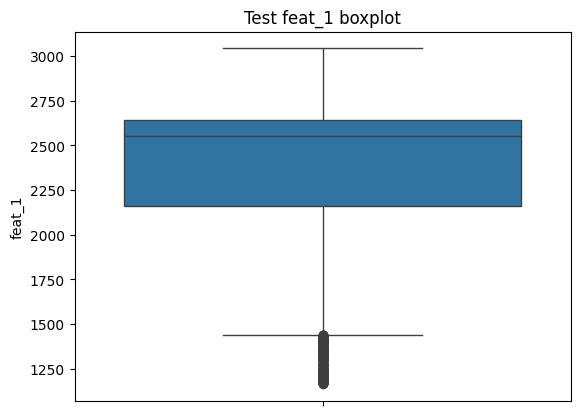

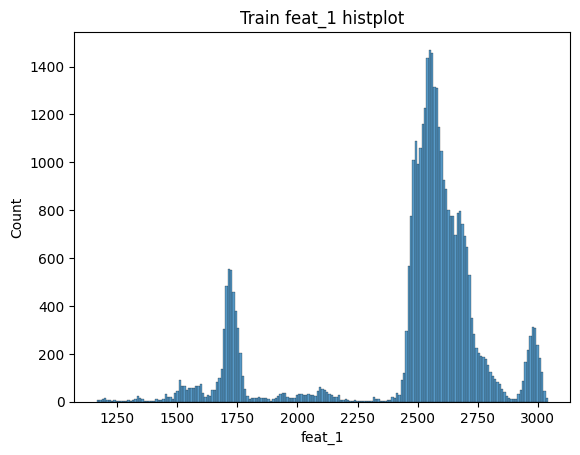

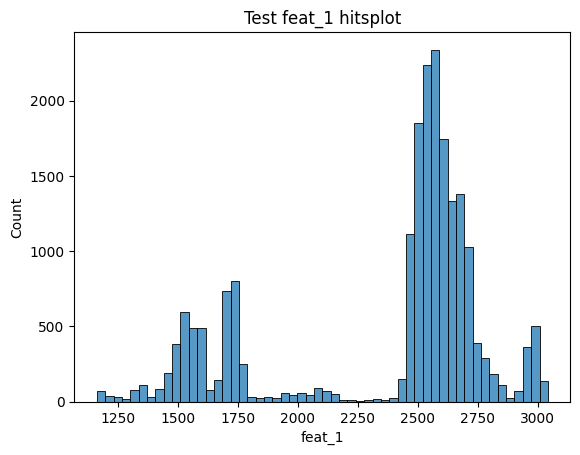

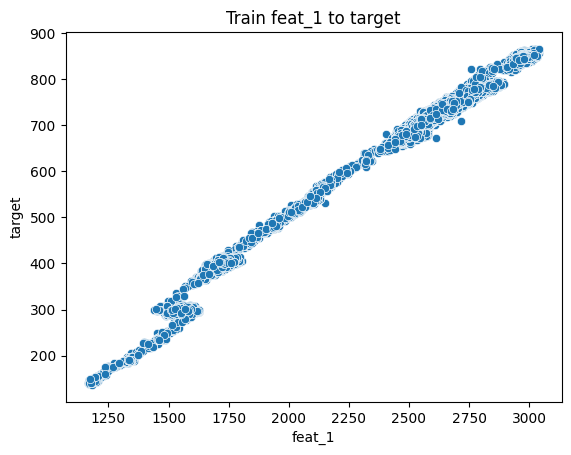

In [12]:
eda_num("feat_1")

Возможно стоит добавить ответы линрега по этой фиче

### feature 2

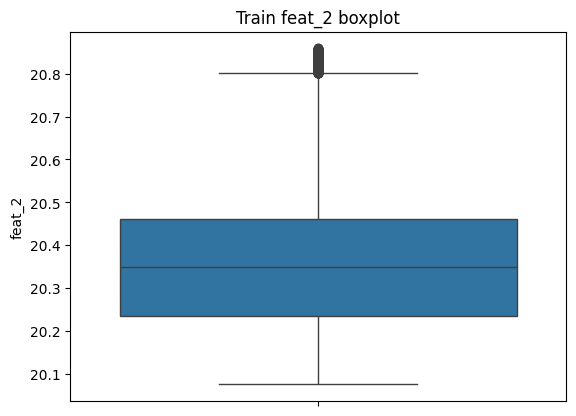

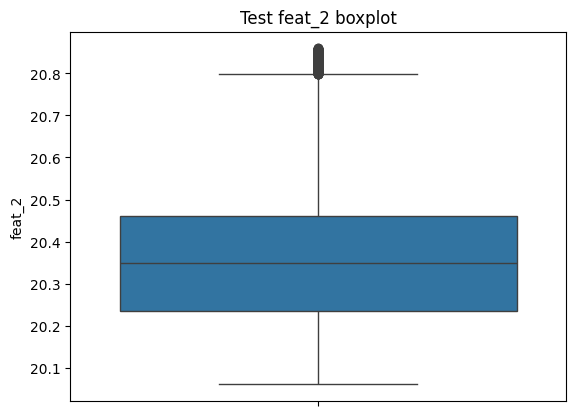

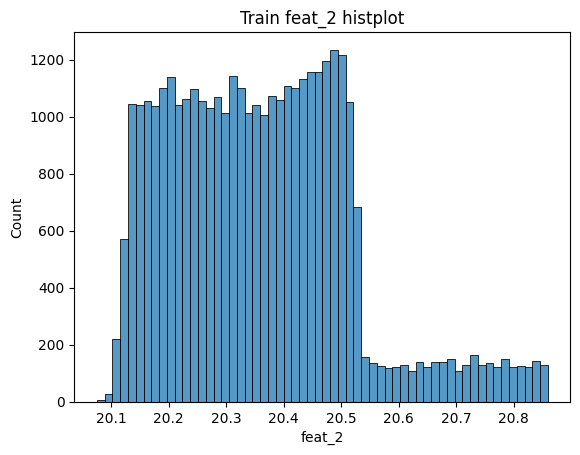

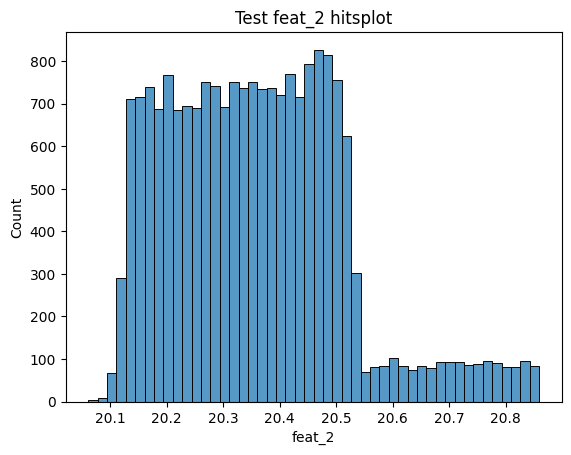

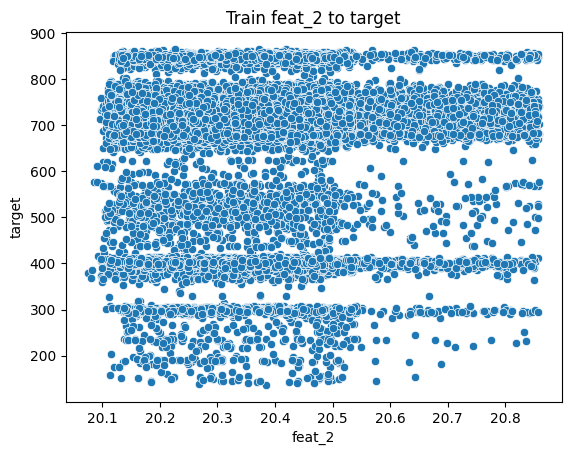

In [13]:
eda_num("feat_2")

какая-то ёбабоба

### feature 3

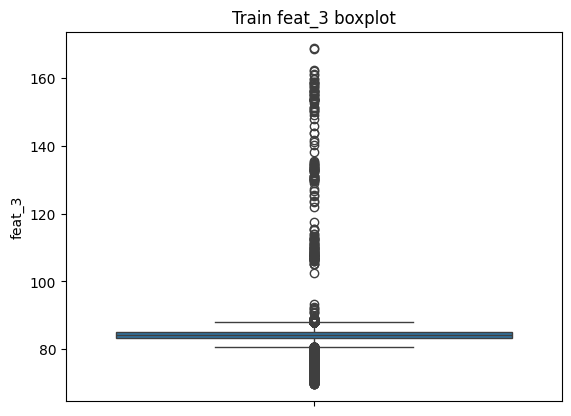

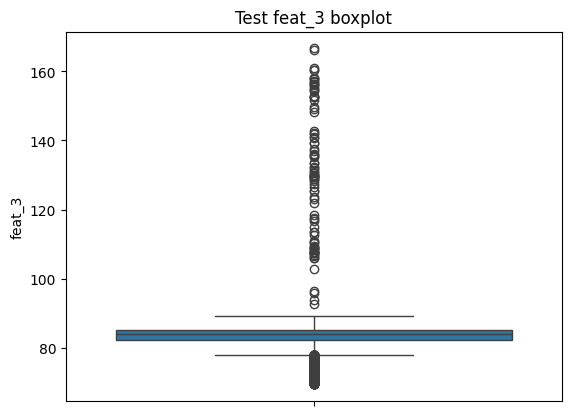

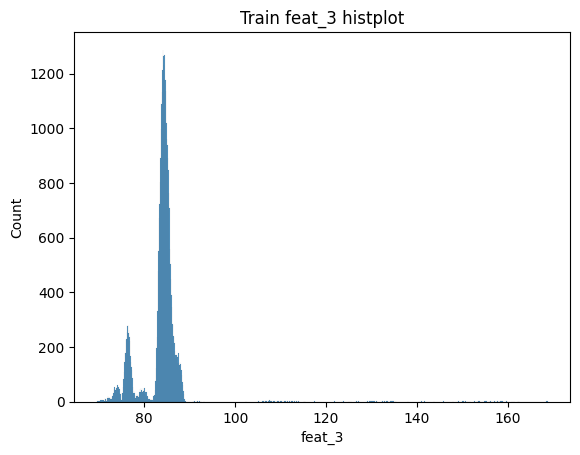

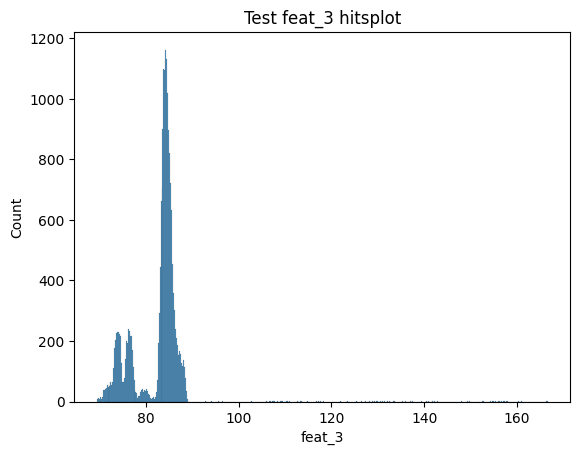

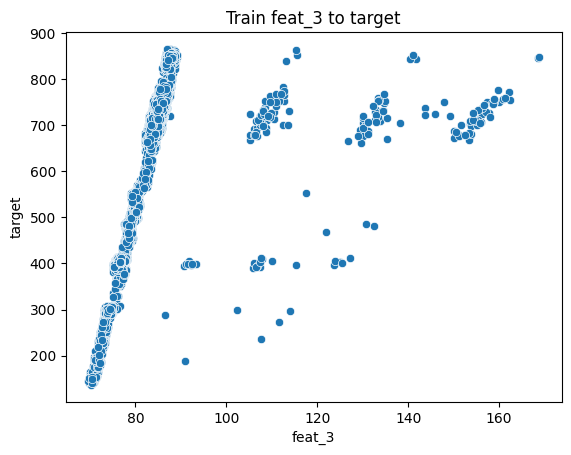

In [14]:
eda_num('feat_3')

Поделить на группы. Опять какие-то линреги

### feature 4

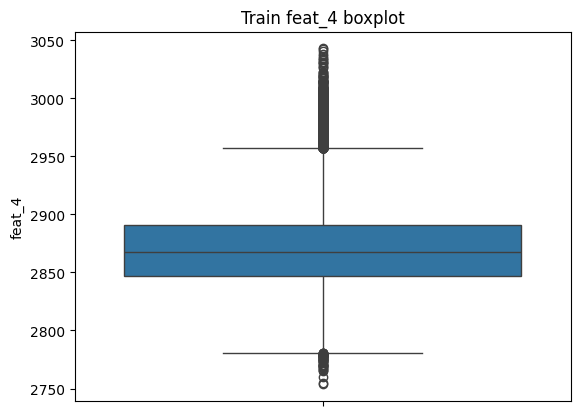

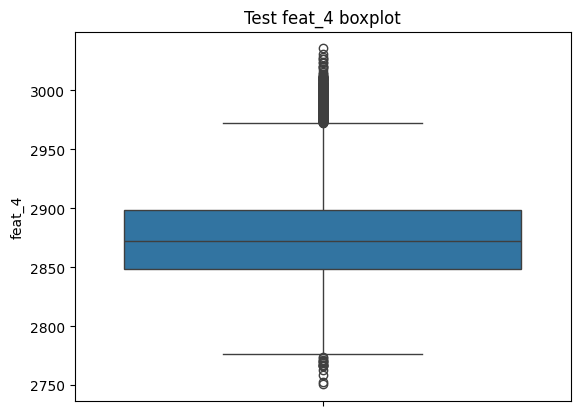

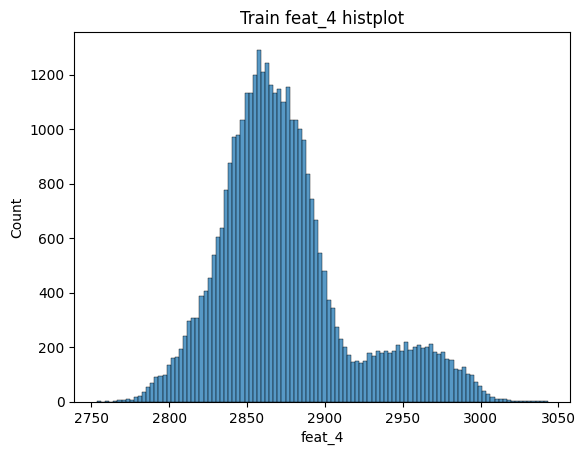

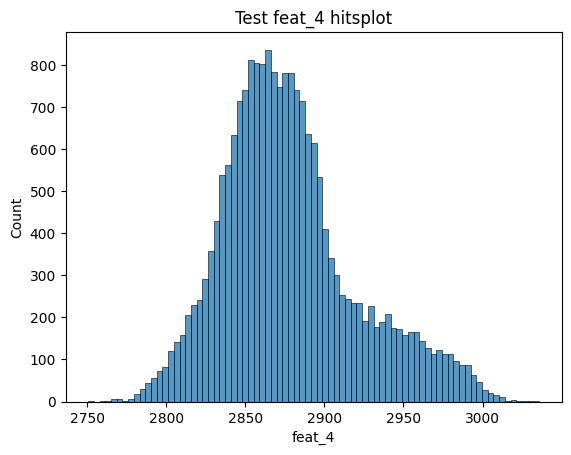

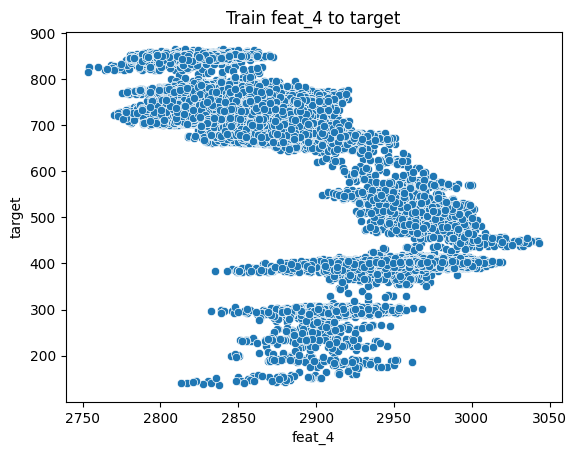

In [15]:
eda_num('feat_4')

Два линрега

### feature 5

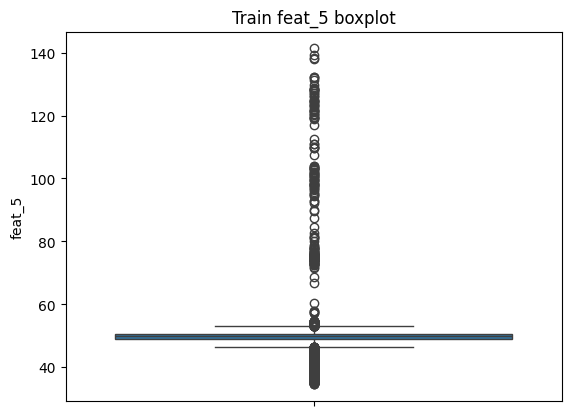

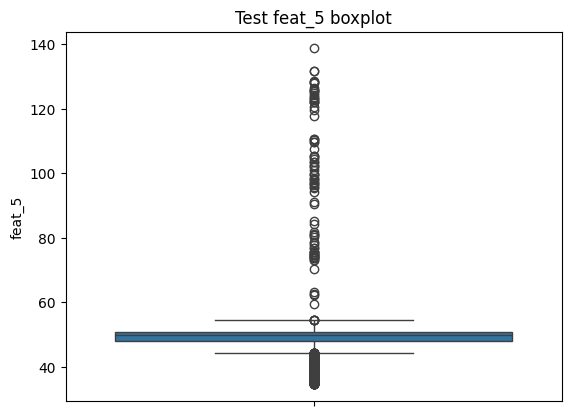

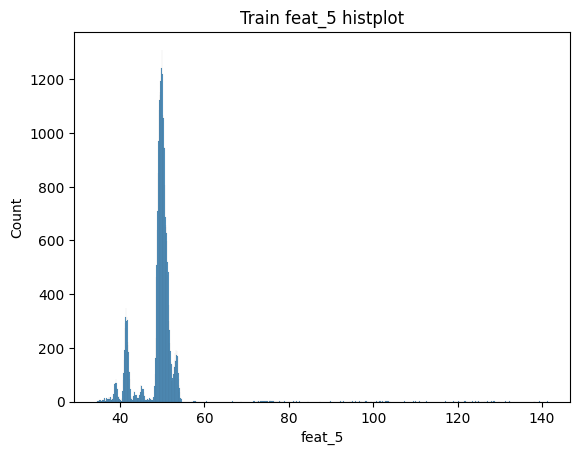

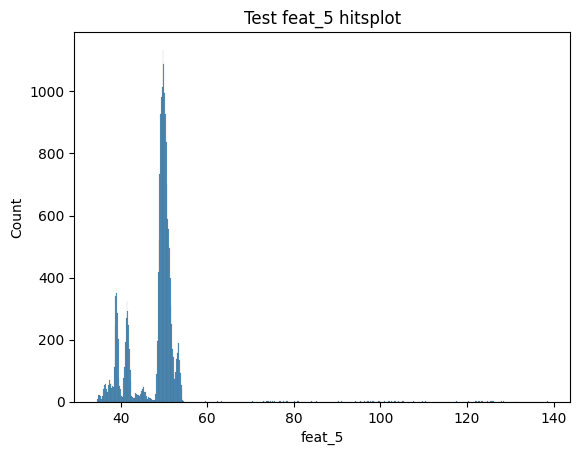

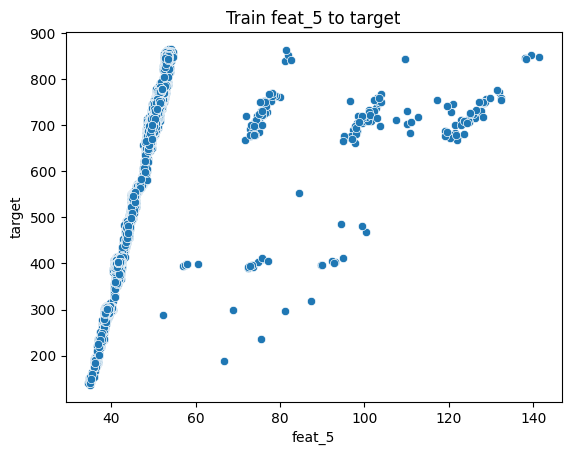

In [16]:
eda_num('feat_5')

### feature 6

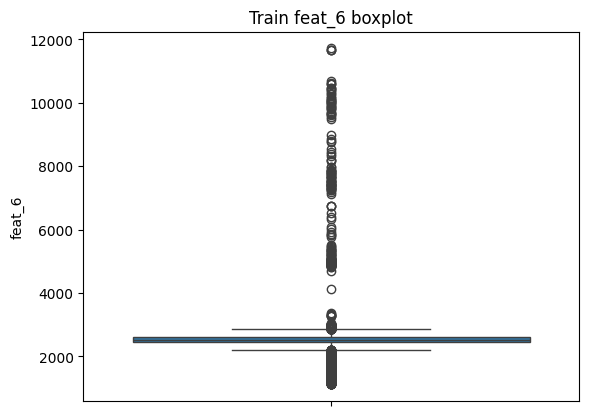

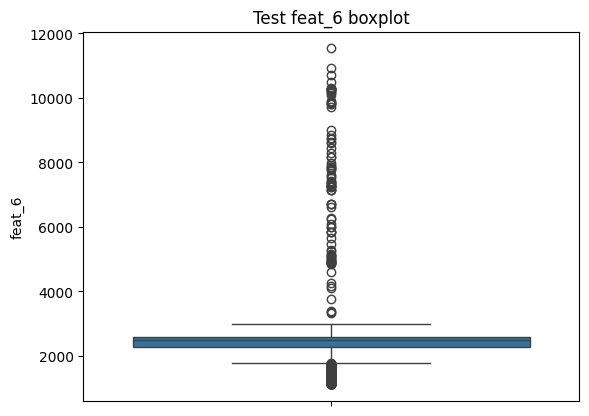

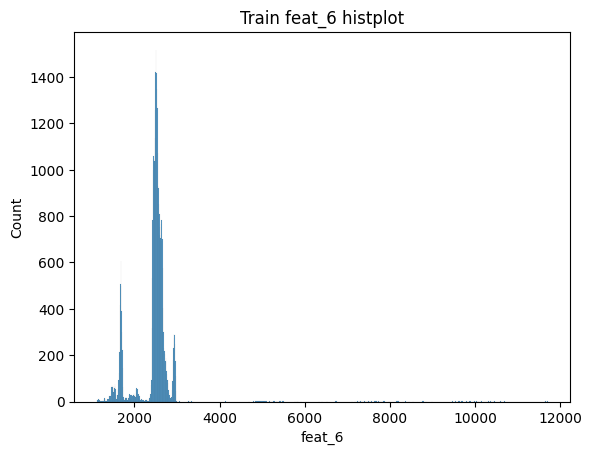

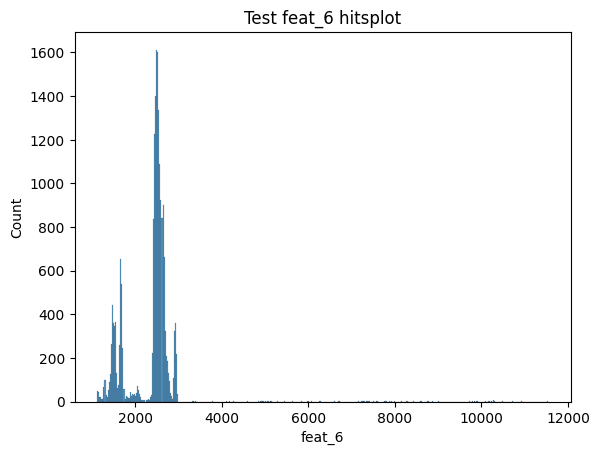

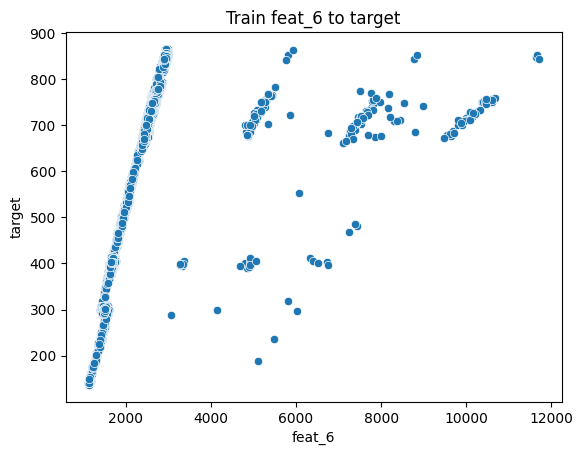

In [17]:
eda_num('feat_6')

линреги

### feature 7

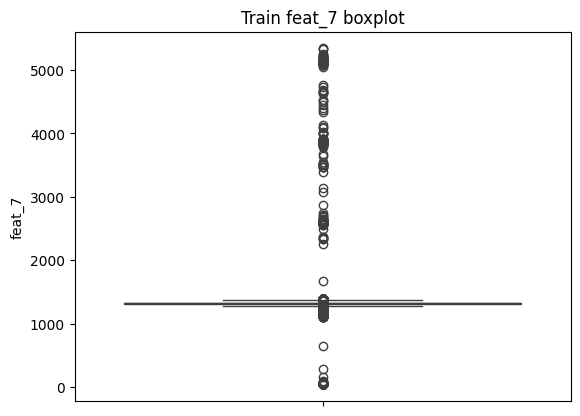

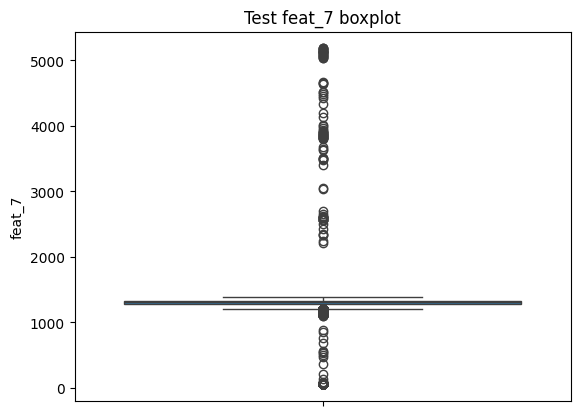

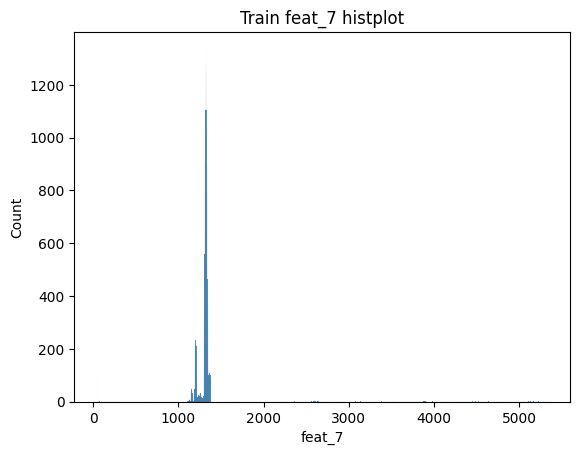

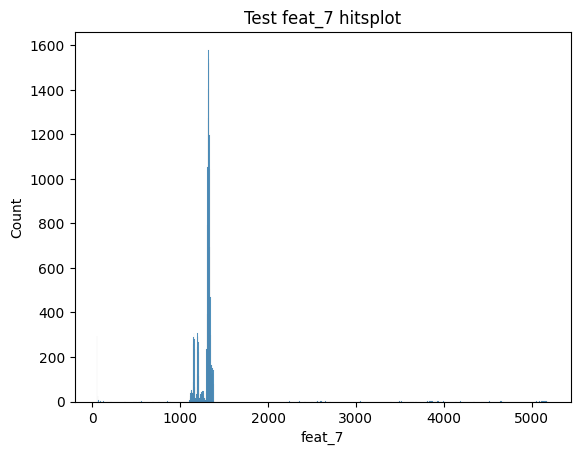

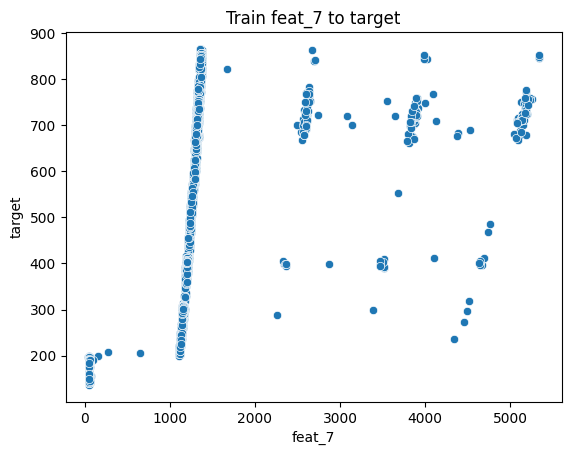

In [18]:
eda_num('feat_7')

### feature 8

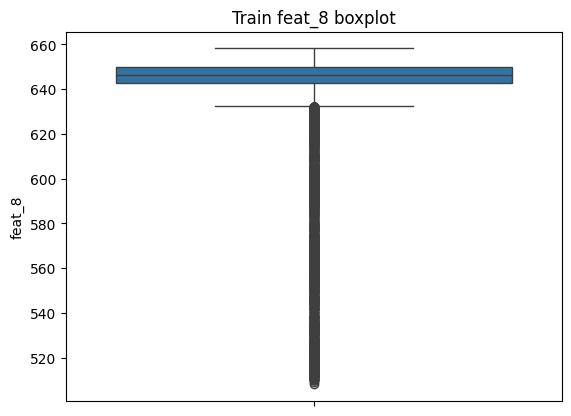

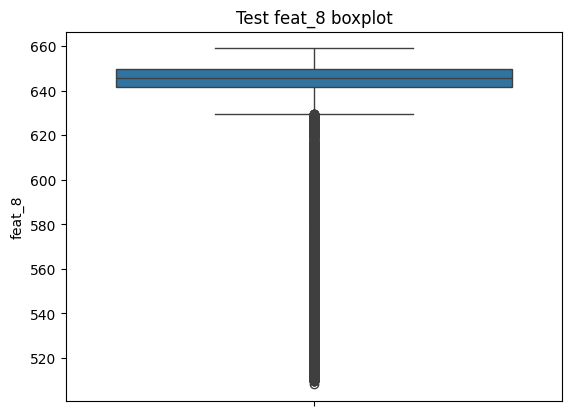

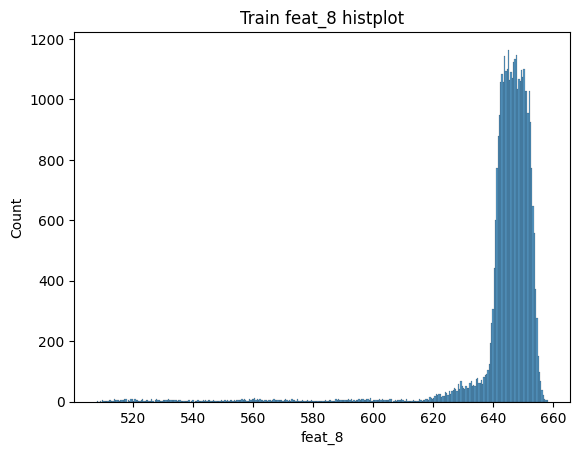

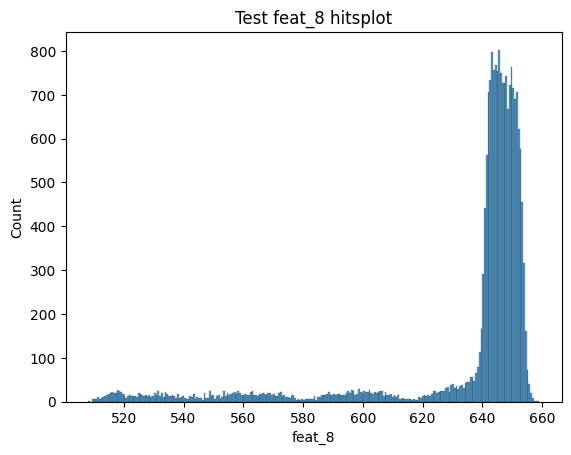

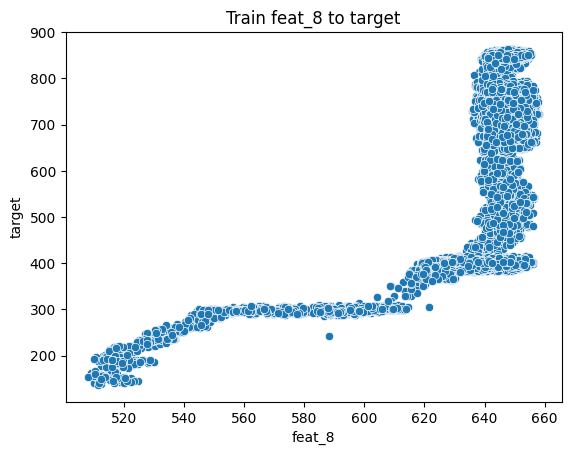

In [19]:
eda_num('feat_8')

### day

<Axes: xlabel='day', ylabel='Count'>

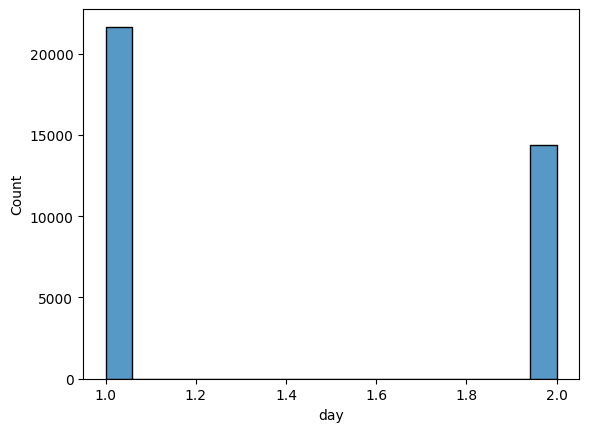

In [20]:
sns.histplot(train_df['day'])

<Axes: xlabel='day', ylabel='Count'>

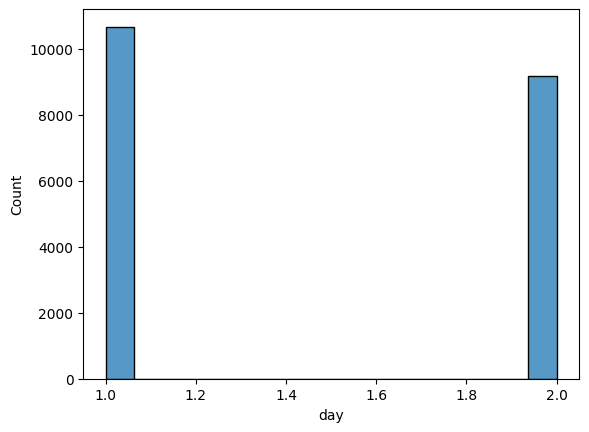

In [21]:
sns.histplot(test_df['day'])

### hour

<Axes: xlabel='hour', ylabel='Count'>

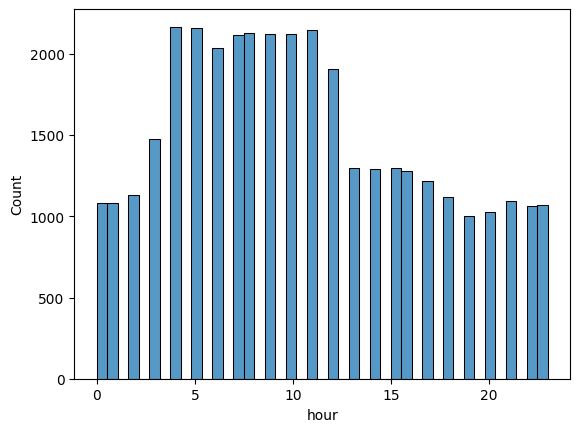

In [22]:
sns.histplot(train_df['hour'])

<Axes: xlabel='hour', ylabel='Count'>

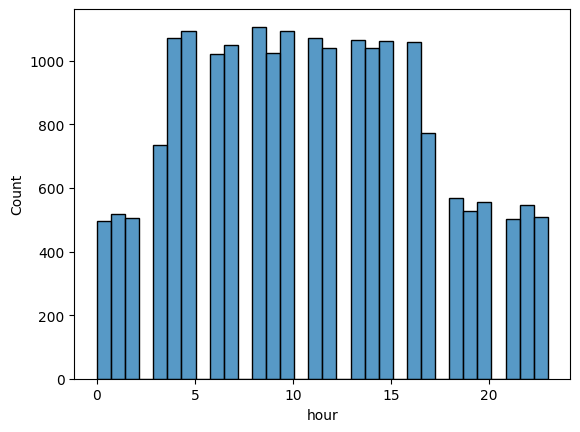

In [23]:
sns.histplot(test_df['hour'])

### Corr matrix

Матрица корреляций:
          feat_0    feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
feat_0  1.000000  0.691265  0.009336  0.978724 -0.533931  0.983117  0.989082   
feat_1  0.691265  1.000000  0.007070  0.689852 -0.762670  0.689417  0.708891   
feat_2  0.009336  0.007070  1.000000  0.003251 -0.010177 -0.000354  0.006579   
feat_3  0.978724  0.689852  0.003251  1.000000 -0.506773  0.991064  0.987752   
feat_4 -0.533931 -0.762670 -0.010177 -0.506773  1.000000 -0.509086 -0.543649   
feat_5  0.983117  0.689417 -0.000354  0.991064 -0.509086  1.000000  0.992603   
feat_6  0.989082  0.708891  0.006579  0.987752 -0.543649  0.992603  1.000000   
feat_7  0.845606  0.295771  0.005010  0.844713 -0.177143  0.845360  0.833489   
feat_8  0.415550  0.571854 -0.004279  0.422582 -0.209921  0.423637  0.405698   
day    -0.357984 -0.513490  0.002366 -0.355659  0.481937 -0.352311 -0.361915   
hour   -0.109879 -0.128646 -0.004957 -0.096635 -0.073525 -0.098743 -0.098225   
minute  0.017003  0.

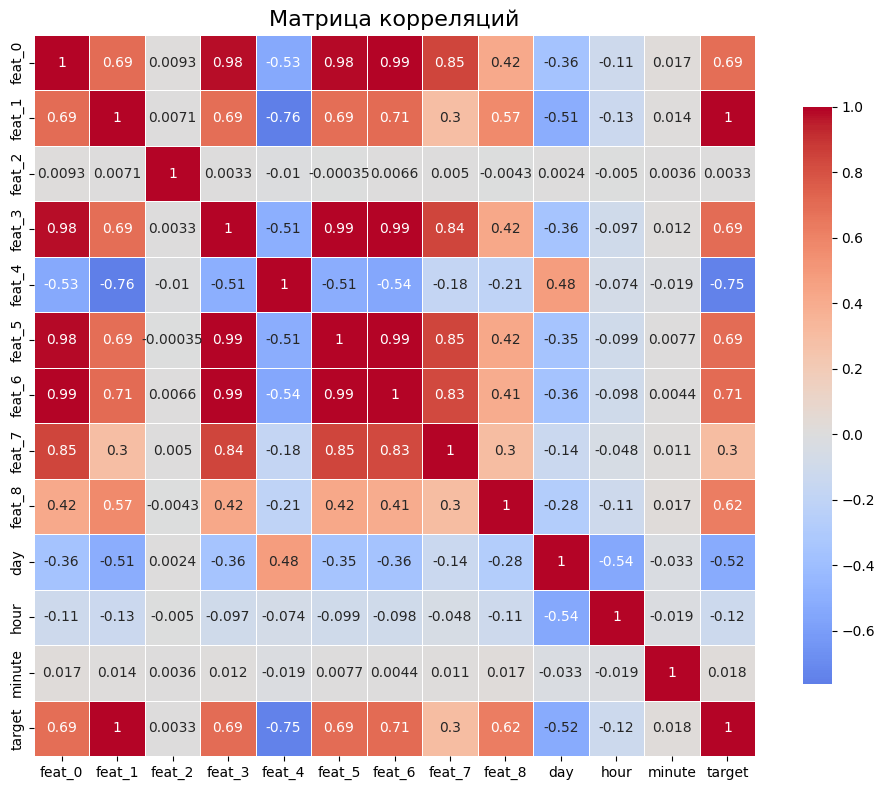

In [24]:
correlation_matrix = train_df.corr()
print("Матрица корреляций:")
print(correlation_matrix)

# 2. Визуализация с помощью seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,  # показывать значения
            cmap='coolwarm',  # цветовая схема
            center=0,  # центр цветовой шкалы
            square=True,  # квадратные ячейки
            linewidths=0.5,  # линии между ячейками
            cbar_kws={"shrink": 0.8})  # размер colorbar
plt.title('Матрица корреляций', fontsize=16)
plt.tight_layout()
plt.show()

## Inference

In [4]:
def clf_train(train, test, target, weight_col, id_col, name_file = 'sub.csv', func_inv = None):

    param = {
    'learning_rate': 0.1,
    'num_leaves': 48,
    'lambda_l1' : 1,
    'lambda_l2' : 1,
    'min_data_in_leaf' : 100,
    'objective': 'mae',
    'verbosity':-1,
    }
    
    predict_test = np.zeros(len(test))

    tr = lgb.Dataset(train, target, weight=weight_col)
    bst = lgb.train(param, tr, num_boost_round=500)
    predict_test = bst.predict(test)
    if func_inv:
        predict_test = func_inv(predict_test)
    sub = pd.DataFrame()
    sub['id'] = id_col
    sub['target'] = predict_test
    sub.to_csv(name_file, index = None)